# Müşteri Kaybı Analizi (Churn Prediction) (Pazarlama Odaklı Sınıflandırma)

Amaç:
- Bu projenin amacı, pazarlama tarafında kritik bir öneme sahip olan "müşteri kaybı (churn)" problemini makine öğrenmesi ile modellemektir.
- Amacımız, bir müşterinin hizmeti bırakıp bırakmayacağını (churn = 1 / 0) geçmiş davranış ve profil bilgilerine bakarak tahmin etmektir.
- Bu örnek hem makine öğrenmesi sınıflandırma adımlarını hem de pazarlama analtiğinin mantığını birlikte öğrenmeyi hedeflemektedir.

Veri seti tanımlama:
- Veri setimiz sentetik olacak
- Toplam örnek sayısı: 1000
  - 500 adet churn = 0 (hizmeti kullanmaya devam eden müşterilelr)
  - 500 adet churn = 1 (hizmeti bırakan müşteriler)
- Dengeli bir veriseti oluştur, herhangi bir sınıf dengesizliği olmasın.
- Features
  1. tenure_months:
    - müşterinin şirkette kaç ay bulunduğunu gösterir.
    - churn = 1 olanlar genelde kısa süre dursun (1 - 20 ay)
    - churn = 0 olanlar daha uzun süre dursun (18 - 60)
  2. monthly_charges:
    - müşterinin aylık fatura tutarı
    - churn 1 olanlar genelde yüksek, churn 0 olanlar ise genelde düşük olacak
  3. contract_type:
    - yıllık ya da aylık sözleşme
    - aylık sözleşmede churn riski yüksek
    - yıllık daha az
  4. has_tech_support
    - yes / no şeklinde olsun
    - teknik destek alma ile ilgili
  5. churn
    - 0 = müşteri kalıyor
    - 1 = müşteri hizmeti bırakıyor

Akış şeması:
1. Gerekli kütüphanelerin içeriye aktarılması
2. Sentetik veri setinin üretilmesi
3. keşifsel veri analizi
  - ilk veri setinin incelenmesi
  - sınıf dağılımlarının öncelenmesi
  - korelasyon matrisinin çizimi
4. Eğitim/test ayrımı ve ön işleme
  - sayısal değişkenler için standard scaler ile normalizasyon
  - kategorik değişkenler için encode etme
5. Karar ağacı algoritmasının eğitilmesi (training)
6. Sonuçların değerlendirilmesi
  - classification report
  - accuracy
  - confusion matrix
  - karar ağaçlarında görselleştirme

In [32]:
#kütüphanelerin içeriye aktarılması
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer  #farklı sütünlara farklı preprocessing adımları uygulamak için
from sklearn.pipeline import Pipeline #preprocessing ile model adımlarını tek bir pipeline da birleştirmek için
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [33]:
# sentetik veri setinin üretimi
def generate_churn_data(n_per_class: int = 500, random_state: int = 0) -> pd.DataFrame:
  """
  Churn veri seti üretme
  Parametreler:
    n_per_class(int):
      - her bir sınıfın üretilecek örnek sayısıdır.
    random_state (int):
      - rastgelelik için kullanılan seed değeri
  Çıktı:
    df (pd.DataFrame): Aşağıdaki sütunlardan oluşan dengeli bir churn verisi döner.
      - tenure_months
      - monthly_charges
      - contract_type
      - has_tech_support
      - churn
  """

  rng = np.random.default_rng(random_state) # rastgele sayı üretmek için generator nesnesi oluşturuyoruz.

  # churn = 0 (stay)
  stay_tenure = rng.integers(18, 60, size = n_per_class) # kalıcı müşteriler için tenure değeri 18-60 ay aralığında olsun
  stay_monthly = rng.uniform(20,80, size = n_per_class) # aylık faturası görece daha düşük olanlar

  stay_contract = rng.choice( # sözleşme tipi
      ["One year", "Month-to-month"], # İki olası değer yıllık veya aylık kontrat
      size = n_per_class,
      p = [0.75, 0.25] # yıllık kontratın olasılığını daha yüksek yapalım
  )
  stay_tech = rng.choice(["Yes","No"], size = n_per_class, p = [0.7,0.3]) # teknik destek durumu

  # churn = 1 (leave)

  churn_tenure = rng.integers(1,20, size = n_per_class) # ayrılan müşteriler için tenure kısa tuttuk
  churn_monthly = rng.uniform(60,120, size = n_per_class) # aylık fature görece yüksek

  churn_contract = rng.choice(["One year", "Month-to-month"], size = n_per_class, p = [0.15,0.85]) # sözleşme tipi
  churn_tech = rng.choice(["Yes","No"], size = n_per_class, p = [0.2,0.8])

  # şimdi dataframeleri oluşturuyoruz
  df_stay = pd.DataFrame({
      "tenure_months": stay_tenure,
      "monthly_charges": stay_monthly,
      "contract_type": stay_contract,
      "has_tech_support": stay_tech,
      "churn": 0
  })

  df_churn = pd.DataFrame({
      "tenure_months": churn_tenure,
      "monthly_charges": churn_monthly,
      "contract_type": churn_contract,
      "has_tech_support": churn_tech,
      "churn": 1
  })

  # iki sınıfı tek bir df de birleştirelim
  df = pd.concat([df_stay, df_churn], ignore_index = True) # iki df alt alta birleştiriyoruz
  df = df.sample (frac = 1, random_state = random_state).reset_index(drop = True) # rastgele karıştırıyoruz

  return df

In [34]:
df = generate_churn_data()
df.head(10)

,tenure_months,monthly_charges,contract_type,has_tech_support,churn
0,19,112.776224,Month-to-month,No,1
1,19,81.413941,Month-to-month,No,1
2,54,54.091539,One year,Yes,0
3,1,115.248549,Month-to-month,No,1
4,9,62.849811,Month-to-month,Yes,1
5,8,62.522564,Month-to-month,No,1
6,19,45.446389,One year,Yes,0
7,39,54.614459,Month-to-month,Yes,0
8,28,71.736531,One year,No,0
9,11,102.424822,One year,Yes,1


In [35]:
# keşifsel veri analizi (exploratory data analysis EDA)
def explore(df: pd.DataFrame) -> None:
  """
  Veri setinin temel özelliklerini inceler ve basit bir korelasyon grafiği çizdirir.
  Parametreler:
    - df: incelenecek olan churn veri seti

  """
  print(df.head(5)) # veri setinin ilk 5 satırını ekrana yazdır

  print(f"Sınıf Dağılımı: \n{df["churn"].value_counts()}") # churn sütununda kaç adet 0  ve 1 olduğunu yazdırır

  print(f"Bilgi: \n{df.info()}")

  print(f"İstatistiksel özellikler: \n {df.describe()}")

  # yalnızca sayısal sütunlar ve churn ile bir korelasyon matrisi oluşturalım
  corr = df[["tenure_months", "monthly_charges", "churn"]].corr()

  plt.figure(figsize = (5,4))
  sns.heatmap(corr, annot = True, cmap = "Blues")
  plt.title("Korelasyon Matrisi")
  plt.tight_layout()
  plt.show()

   tenure_months  monthly_charges   contract_type has_tech_support  churn
0             19       112.776224  Month-to-month               No      1
1             19        81.413941  Month-to-month               No      1
2             54        54.091539        One year              Yes      0
3              1       115.248549  Month-to-month               No      1
4              9        62.849811  Month-to-month              Yes      1
Sınıf Dağılımı: 
churn
1    500
0    500
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tenure_months     1000 non-null   int64  
 1   monthly_charges   1000 non-null   float64
 2   contract_type     1000 non-null   object 
 3   has_tech_support  1000 non-null   object 
 4   churn             1000 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3

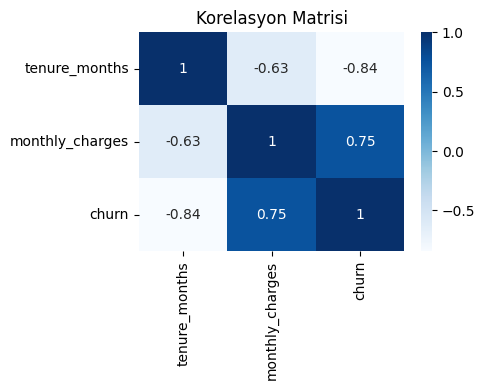

In [36]:
explore(df)

In [37]:
# preprocessing ve model training (ön işleme ve modelin eğitilmesi)
def train(df: pd.DataFrame):
  """
    Verilen veri seti üzerinden Decision Tree ile sınıflandırma
    Parametreler:
      - df: churn veri
    Çıktı:
      - model
      - X_test: featureler
      - y_test: etiketler
  """
  X = df.drop("churn", axis = 1) # etilet (churn) sütunu dışındaki tüm sütunları feature olarak alıyoruz
  y = df["churn"] # hedef değişken

  numeric_cols = ["tenure_months", "monthly_charges"] # sayısal features
  categorical_cols = ["contract_type", "has_tech_support"] # kategorik features

  # verimizi eğitim ve test olarak ikiye ayıralım
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)

  # sayısal sütunları ölçeklemek için standard scaler nesnesi tanımla
  numeric_transform = StandardScaler()

  # kategorik değişkenler için de one hot encoder tanımla
  categorical_transform = OneHotEncoder(handle_unknown="ignore")

  # columnTransfer ile farklı sütun gruplarına farklı dönüşümler uygula
  preprocessor = ColumnTransformer(
      transformers = [ # birden fazla dönüştürücüyü liste içerisinde tanımlayabiliriz
            ("num", numeric_transform, numeric_cols),
           ("cat", categorical_transform, categorical_cols)
           ]
  )

  # decision tree modeli tanımla
  tree_clf = DecisionTreeClassifier(
      max_depth = 4, # ağacın derinliğini sınırlayarak aşırı öğrenmeyi azaltır
      random_state = 0
  )

  # pipeline ile preprocessing ve modeli tek bir akışta birleştiriyoruz
  model = Pipeline(
      steps = [
          ("preprocess", preprocessor),
          ("tree", tree_clf)
      ]
  )
  model.fit(X_train, y_train)

  return model, X_test, y_test


In [38]:
model, X_test, y_test = train(df)

In [39]:
model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure_months',
                                                   'monthly_charges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['contract_type',
                                                   'has_tech_support'])])),
                ('tree', DecisionTreeClassifier(max_depth=4, random_state=0))])

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer  #farklı sütünlara farklı preprocessing adımları uygulamak için
from sklearn.pipeline import Pipeline #preprocessing ile model adımlarını tek bir pipeline da birleştirmek için
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


# test ve değerlendirme
"""
tahminleri üret
classification report ile precision, recall, f1 ve accuracy değerlerini yazdrılarım
accuracy score
confusion matrix
karar ağacının görselleştirilmesi
"""
def evaluate(model, X_test: pd.DataFrame, y_test: pd.Series) -> None:
  """
  eğitilmiş modeli test verisi üzerinde değerlendir ve sonuçları detaylı şekilde yorumla
  parametreler:
    - model: train ile eğitilmiş modelimiz
    - X_test: test verisetinin özellikleri
    - y_test: test verisetinin gerçek churn etiketleri
  """
  y_pred  = model.predict(X_test) # modeli kullanarak test verisi için tahminler üret

  print("Classification report")
  print(classification_report(y_test, y_pred, target_names = ["Stay", "Churn"]))

  print("Accuracy")
  print(accuracy_score(y_test, y_pred))

  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(cm, display_labels = ["Stay", "Churn"])
  disp.plot(cmap = "Greens")
  plt.title("Confusion Matrix - Churn Prediction")
  plt.tight_layout()
  plt.show()

  tree_clf: DecisionTreeClassifier = model.named_steps["tree"] # pipeline içerisindeki karar ağacına erişiyor
  ohe: OneHotEncoder = model.named_steps["preprocess"].named_transformers_["cat"] # preprocessor içerisindeki one hot encodera erişiyoruz

  ohe_features = ohe.get_feature_names_out(["contract_type", "has_tech_support"]) # one hot encoder

  numeric_cols = ["tenure_months", "monthly_charges"] # sayısal sütun isimlerimiz
  feature_names = numeric_cols + list(ohe_features) # tüm feature isimlerini sayısal ve kategorik olacak şekilde birleştiriyoruz

  plt.figure(figsize = (16,10)) # karar ağacı görselleştirilmesi için figure
  plot_tree(
      tree_clf,
      feature_names = feature_names, # düğümlerin feature isimleri
      class_names = ["Stay", "Churn"],
      filled = True,
      rounded = True,
      fontsize = 8
  )

  plt.title("Decision Tree Classifier")
  plt.tight_layout()
  plt.show()


Classification report
              precision    recall  f1-score   support

        Stay       1.00      0.98      0.99       100
       Churn       0.98      1.00      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

Accuracy
0.99


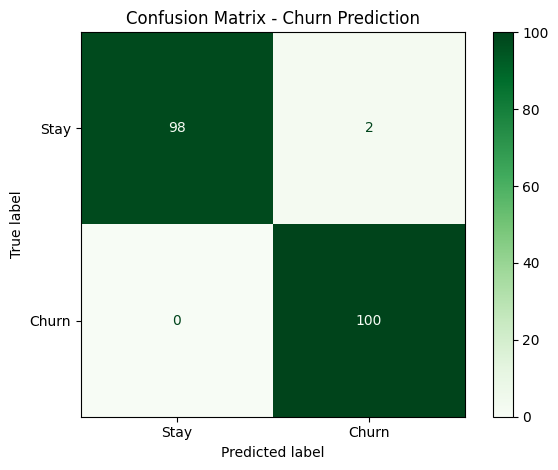

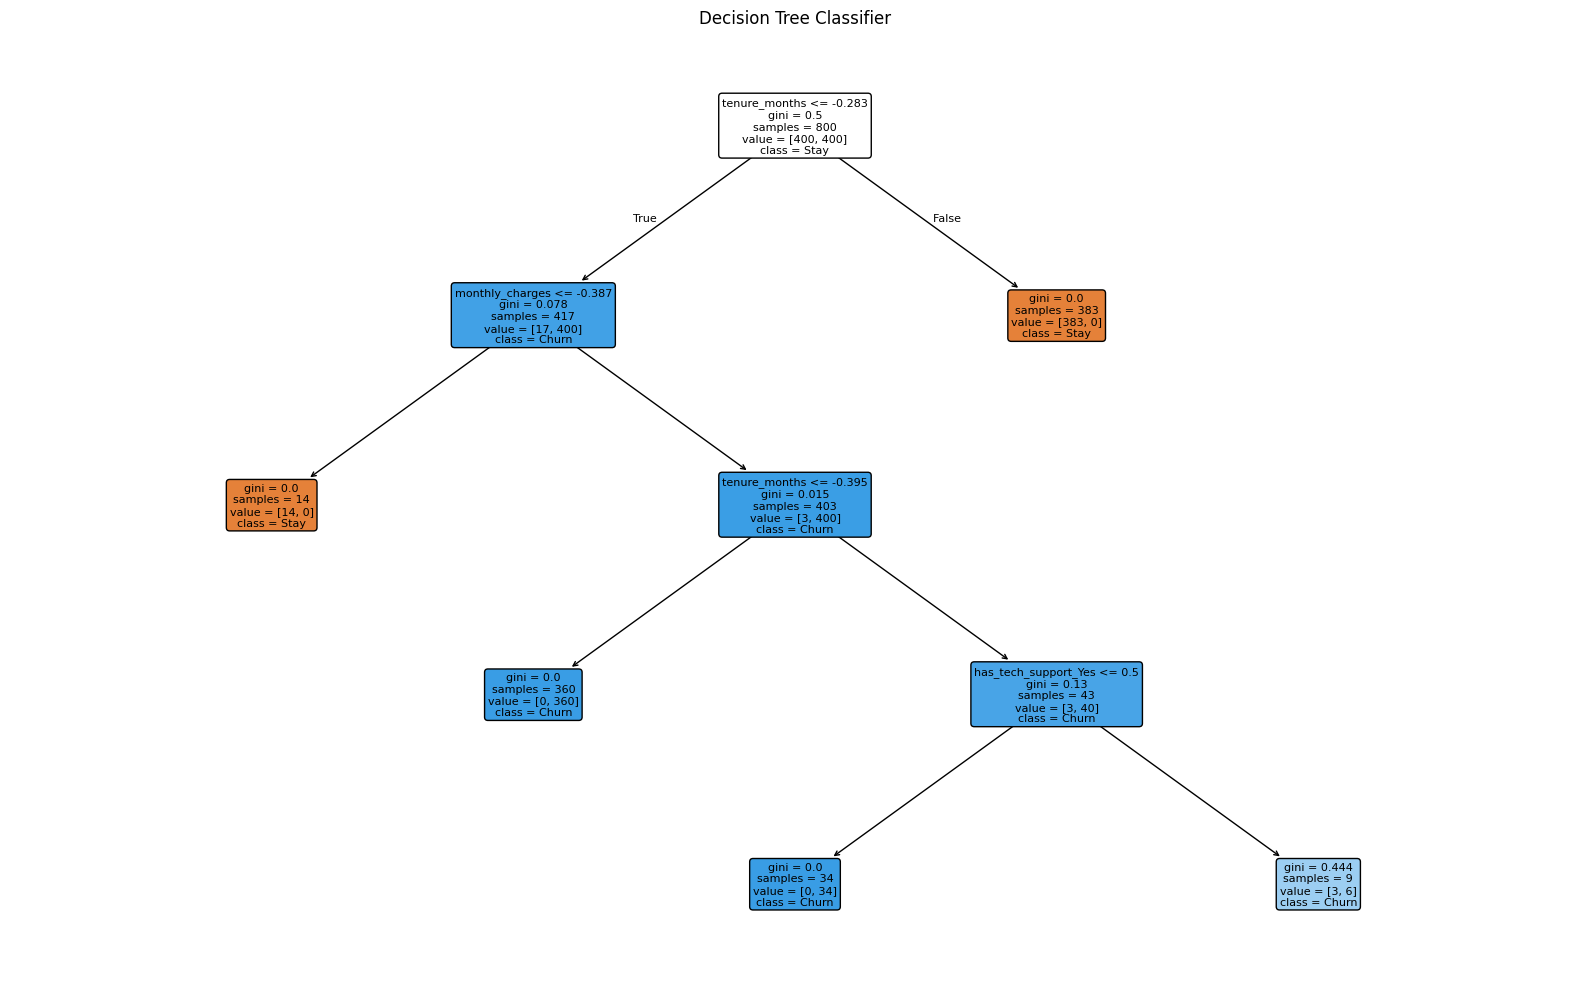

In [41]:
evaluate(model, X_test, y_test)